<a href="https://colab.research.google.com/github/ankitta-singh/machinelearning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive(1).zip to archive(1) (2).zip


In [ ]:
import zipfile
with zipfile.ZipFile("archive(1).zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os
os.listdir("dataset")

['Churn_Modelling.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
dataset= pd.read_csv('dataset/Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
dataset.shape

(10000, 14)

In [ ]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
dataset.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
dataset.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
X = dataset.drop('Exited', axis=1)
y = dataset['Exited']

In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
y.value_counts()

,count
Exited,
0,7963
1,2037


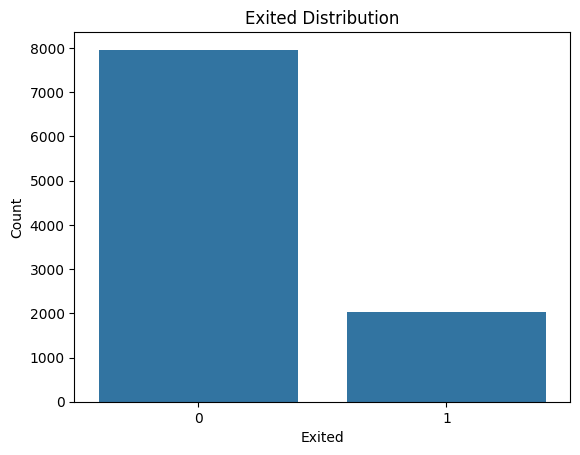

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)

plt.title("Exited Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

In [ ]:
dataset.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
dataset.select_dtypes(include='object').columns

Index(['Surname', 'Geography', 'Gender'], dtype='object')

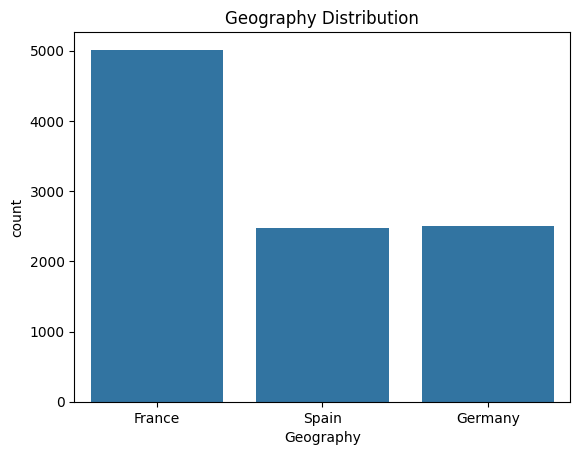

In [ ]:
dataset['Geography'].value_counts()
dataset['Geography'].value_counts(normalize=True) * 100
sns.countplot(data=dataset, x='Geography')

plt.title('Geography Distribution')
plt.show()

In [ ]:
dataset['Surname'].nunique()
dataset['Surname'].value_counts().head(10)

,count
Surname,
Smith,32
Scott,29
Martin,29
Walker,28
Brown,26
Genovese,25
Yeh,25
Shih,25
Wright,24


In [ ]:
dataset['Surname'].nunique()
dataset.shape[0]

10000

In [ ]:
dataset['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
pd.crosstab(
    dataset['Geography'],
    dataset['Exited'],
    normalize='index'
) * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [ ]:


dataset['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


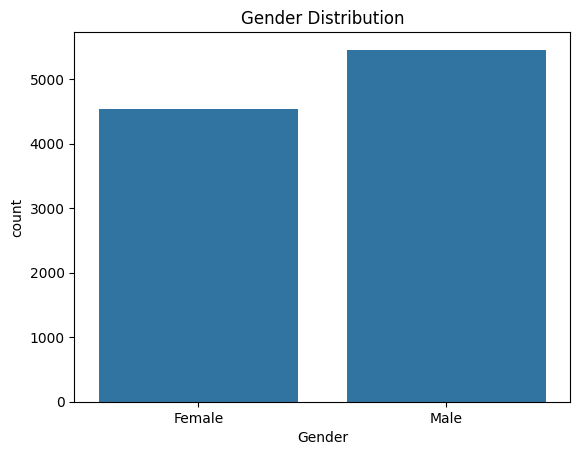

In [ ]:
dataset['Gender'].value_counts()
dataset['Gender'].value_counts(normalize=True) * 100
sns.countplot(data=dataset, x='Gender')

plt.title('Gender Distribution')
plt.show()

In [ ]:
pd.crosstab(dataset['Gender'], dataset['Exited'])

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [ ]:
pd.crosstab(
    dataset['Gender'],
    dataset['Exited'],
    normalize='index'
) * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [ ]:
dataset.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


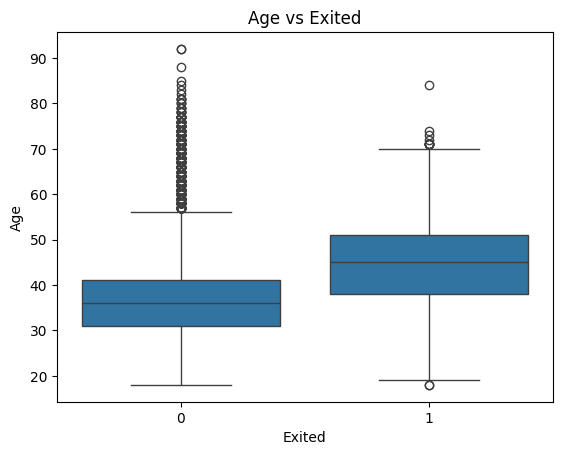

In [ ]:
sns.boxplot(data=dataset, x='Exited', y='Age')

plt.title('Age vs Exited')
plt.xlabel('Exited')
plt.ylabel('Age')

plt.show()

In [ ]:
dataset.groupby('Exited')['Balance'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09


In [ ]:
dataset.groupby('Exited')['CreditScore'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,651.853196,95.653837,405.0,585.0,653.0,718.0,850.0
1,2037.0,645.351497,100.321503,350.0,578.0,646.0,716.0,850.0


In [ ]:
dataset.groupby('Exited')['NumOfProducts'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,1.544267,0.509536,1.0,1.0,2.0,2.0,3.0
1,2037.0,1.475209,0.801521,1.0,1.0,1.0,2.0,4.0


In [ ]:
pd.crosstab(
    dataset['NumOfProducts'],
    dataset['Exited'],
    normalize='index'
) * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [ ]:
dataset.groupby('Exited')['Tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,5.033279,2.880658,0.0,3.0,5.0,7.0,10.0
1,2037.0,4.932744,2.936106,0.0,2.0,5.0,8.0,10.0


In [ ]:
pd.crosstab(
    dataset['HasCrCard'],
    dataset['Exited'],
    normalize='index'
) * 100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


In [ ]:
pd.crosstab(
    dataset['IsActiveMember'],
    dataset['Exited'],
    normalize='index'
) * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [ ]:
dataset.groupby('Exited')['EstimatedSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,99738.391772,57405.586966,90.07,50783.49,99645.04,148609.955,199992.48
1,2037.0,101465.677531,57912.418071,11.58,51907.72,102460.84,152422.910,199808.10


In [ ]:
X = dataset.drop(
    ['RowNumber', 'CustomerId', 'Surname', 'Exited'],
    axis=1
)

y = dataset['Exited']

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
X = pd.get_dummies(
    X,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
X.dtypes

,0
CreditScore,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_Germany,bool
Geography_Spain,bool


In [ ]:
X.shape

(10000, 11)

In [ ]:
y.value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Exited
0    79.625
1    20.375
Name: proportion, dtype: float64
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(8000, 11)

In [ ]:
X_test_scaled.shape

(2000, 11)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(16, activation='relu', input_shape=(11,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7206 - loss: 0.5831 - val_accuracy: 0.8000 - val_loss: 0.4872
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8031 - loss: 0.4577 - val_accuracy: 0.8131 - val_loss: 0.4413
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8147 - loss: 0.4223 - val_accuracy: 0.8294 - val_loss: 0.4186
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8272 - loss: 0.3996 - val_accuracy: 0.8431 - val_loss: 0.3956
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8392 - loss: 0.3820 - val_accuracy: 0.8531 - val_loss: 0.3768
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.3688 - val_accuracy: 0.8562 - val_loss: 0.3633
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8522 - loss: 0.3605 - val_accuracy: 0.8619 - val_loss: 0.3547
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8545 - loss: 0.3552 - val_accuracy: 0.

In [ ]:
y_prob = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1538   55]
 [ 235  172]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1593
           1       0.76      0.42      0.54       407

    accuracy                           0.85      2000
   macro avg       0.81      0.69      0.73      2000
weighted avg       0.85      0.85      0.84      2000



In [ ]:
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


In [ ]:
model_weighted = Sequential([
    Dense(16, activation='relu', input_shape=(11,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_weighted.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_weighted = model_weighted.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6894 - loss: 0.6552 - val_accuracy: 0.6706 - val_loss: 0.6084
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6892 - loss: 0.5799 - val_accuracy: 0.6894 - val_loss: 0.5792
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7058 - loss: 0.5598 - val_accuracy: 0.6919 - val_loss: 0.5759
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7127 - loss: 0.5461 - val_accuracy: 0.7006 - val_loss: 0.5627
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7230 - loss: 0.5315 - val_accuracy: 0.7269 - val_loss: 0.5350
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7359 - loss: 0.5179 - val_accuracy: 0.7444 - val_loss: 0.5097
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7478 - loss: 0.5069 - val_accuracy: 0.7500 - val_loss: 0.5023
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7561 - loss: 0.4969 - val_accuracy: 0.

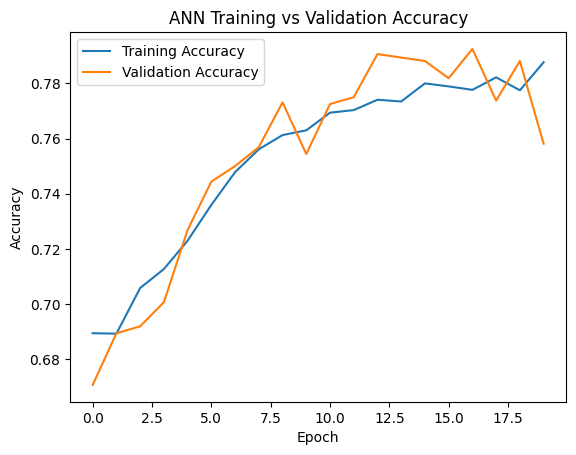

In [88]:
import matplotlib.pyplot as plt

plt.plot(history_weighted.history['accuracy'], label='Training Accuracy')
plt.plot(history_weighted.history['val_accuracy'], label='Validation Accuracy')

plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

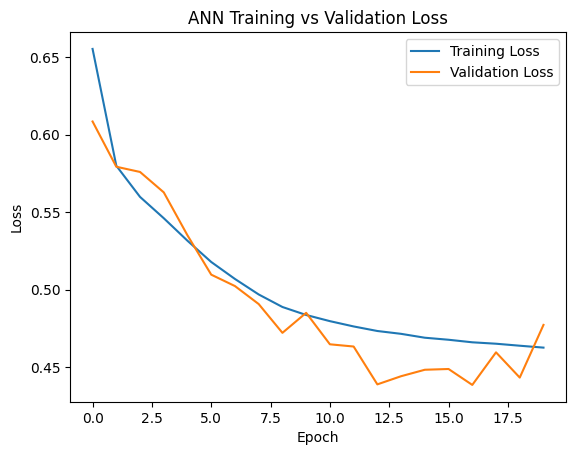

In [89]:
plt.plot(history_weighted.history['loss'], label='Training Loss')
plt.plot(history_weighted.history['val_loss'], label='Validation Loss')

plt.title('ANN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [90]:
y_prob_weighted = model_weighted.predict(X_test_scaled)

y_pred_weighted = (y_prob_weighted >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [91]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_weighted))

print(classification_report(y_test, y_pred_weighted))

[[1187  406]
 [  84  323]]
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1593
           1       0.44      0.79      0.57       407

    accuracy                           0.76      2000
   macro avg       0.69      0.77      0.70      2000
weighted avg       0.83      0.76      0.78      2000



In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_prob_weighted >= threshold).astype(int)

    print("Threshold:", threshold)
    print("Accuracy :", round(accuracy_score(y_test, y_pred_threshold), 3))
    print("Precision:", round(precision_score(y_test, y_pred_threshold), 3))
    print("Recall   :", round(recall_score(y_test, y_pred_threshold), 3))
    print("F1       :", round(f1_score(y_test, y_pred_threshold), 3))
    print("-" * 30)

Threshold: 0.3
Accuracy : 0.612
Precision: 0.334
Recall   : 0.914
F1       : 0.489
------------------------------
Threshold: 0.4
Accuracy : 0.69
Precision: 0.383
Recall   : 0.855
F1       : 0.529
------------------------------
Threshold: 0.5
Accuracy : 0.755
Precision: 0.443
Recall   : 0.794
F1       : 0.569
------------------------------
Threshold: 0.6
Accuracy : 0.805
Precision: 0.515
Recall   : 0.703
F1       : 0.595
------------------------------
Threshold: 0.7
Accuracy : 0.846
Precision: 0.62
Recall   : 0.629
F1       : 0.624
------------------------------


In [93]:
final_threshold = 0.7

y_pred_final = (y_prob_weighted >= final_threshold).astype(int)

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Confusion Matrix:
[[1436  157]
 [ 151  256]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.62      0.63      0.62       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.85      0.85      2000

